# Pronóstico de Ventas Mensuales con Prophet

Este notebook pronostica el **volumen de ventas mensuales por artículo** usando exclusivamente
**[Prophet](https://facebook.github.io/prophet/)**.

Flujo de trabajo:

1. Carga de datos desde Excel (formato *wide*).
2. Transformación *wide → long*, parseo de fechas (español → inglés) y ordenamiento.
3. Análisis exploratorio (EDA) básico.
4. Manejo de nulos y validación de consistencia (no-negativos).
5. Preparación para Prophet (columnas `ds` / `y`).
6. **Optimización de hiperparámetros con Búsqueda Aleatoria (Random Search)** evaluada con
   *cross-validation* de series temporales (`cross_validation` + `performance_metrics`).
7. Evaluación en un conjunto de prueba (MSE, RMSE, MAE, R²).
8. Pronóstico a 12 meses reutilizando los modelos finales entrenados en la evaluación (7.1).
9. Combinación histórico + pronóstico, visualización y export a Excel
   (`Articulo | Fecha | Ventas | Tipo`).

> Se mantiene **Random Search** como algoritmo de optimización para ser consistente con la
> versión previa del notebook (que usaba Keras Tuner `RandomSearch` para el LSTM).

> **Dónde vive el código:** el cálculo está en el paquete `planificacion/forecast/`
> (`datos`, `metricas`, `modelo`, `evaluacion`, `resultados`, `graficos`) y los parámetros en
> `planificacion/config.py`. Este notebook solo orquesta y documenta. Las funciones puras
> tienen tests en `tests/` (`python -m pytest tests/`).


## 0. Instalación de dependencias

Ejecutar solo si Prophet u `openpyxl` no están instalados (p. ej. en Google Colab).

In [1]:
# !pip install prophet openpyxl -q

## 0.1 Imports y configuración global

Todos los imports se centralizan al inicio. También fijamos la **semilla** para que la
búsqueda aleatoria sea reproducible y silenciamos los logs verbosos de Prophet/cmdstanpy.

In [2]:
import random

import pandas as pd

from planificacion import io_datos
from planificacion.config import ForecastConfig
from planificacion.forecast import datos, evaluacion, graficos, modelo, resultados

# Silencia los logs verbosos de Prophet/cmdstanpy (no los warnings de pandas).
modelo.silenciar_logs_prophet()
graficos.aplicar_estilo()


C:\Users\nacho\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing plotly failed. Interactive plots will not work.


## 0.2 Parámetros globales

Toda la configuración del notebook está concentrada acá: origen y salida de datos,
semilla, Random Search / cross-validation, y horizontes de evaluación y pronóstico.
Modificar esta celda es suficiente para re-ejecutar el análisis con otros criterios.

In [3]:
cfg = ForecastConfig()

print("✅ Parámetros configurados")
print(cfg.resumen())


✅ Parámetros configurados
N_ITER=20 | CV: 730 days/90 days/180 days | métrica=rmse
Hold-out: 12 meses | Horizonte de pronóstico: 12 meses


## 1. Carga de Datos desde Excel (formato wide)

Cargamos el DataFrame desde el archivo de Excel, con la columna `Articulo` y una columna por mes
(`ene-23`, `feb-23`, ...).

> El origen está definido en `EXCEL_URL` (celda de **Parámetros globales**, sección 0.2).

In [4]:
df_wide = io_datos.cargar_ventas(cfg.excel_url, cfg.cache_ventas)

print(f"Dimensiones: {df_wide.shape[0]} artículos x {df_wide.shape[1] - 1} meses")
display(df_wide.head())


Dimensiones: 3 artículos x 36 meses


,Articulo,ene-23,feb-23,mar-23,abr-23,may-23,jun-23,jul-23,ago-23,sep-23,...,mar-25,abr-25,may-25,jun-25,jul-25,ago-25,sep-25,oct-25,nov-25,dic-25
0,CRONOS-N04,5895,6405,11145,3484,7805,12953,8779,11708,10262,...,15453,12199,13082,13720,11884,12577,12873,11119,11751,10698
1,HORIZON-M09,4483,3552,4874,2613,3299,3209,3855,1837,2823,...,3726,2941,3154,3308,2865,3032,3104,2681,2833,2580
2,TAURO 2-N04,1525,1914,3443,1647,3016,5774,1033,2530,1470,...,4559,3599,3859,4047,3506,3710,3797,3280,3467,3156


## 2. Transformación de Datos (Wide → Long, Fechas y Ordenamiento)

Convertimos el dataset a formato *long* (`Articulo`, `Fecha`, `Volumen_Ventas`), parseamos las
fechas en español a `datetime` y ordenamos como serie temporal por artículo.

In [5]:
df_long = datos.pasar_a_formato_largo(df_wide)

# Histórico reutilizado en la visualización y en el export final
df_historico = df_long[['Articulo', 'Fecha', 'Volumen_Ventas']].copy()

display(df_long.head())
print(f"Rango de fechas: {df_long['Fecha'].min():%Y-%m} a {df_long['Fecha'].max():%Y-%m}")
print(f"Artículos: {df_long['Articulo'].nunique()} | Observaciones por artículo: "
      f"{df_long.groupby('Articulo').size().to_dict()}")


,Articulo,Volumen_Ventas,Fecha
0,CRONOS-N04,5895,2023-01-01
1,CRONOS-N04,6405,2023-02-01
2,CRONOS-N04,11145,2023-03-01
3,CRONOS-N04,3484,2023-04-01
4,CRONOS-N04,7805,2023-05-01


Rango de fechas: 2023-01 a 2025-12
Artículos: 3 | Observaciones por artículo: {'CRONOS-N04': 36, 'HORIZON-M09': 36, 'TAURO 2-N04': 36}


## 3. Análisis Exploratorio de Datos (EDA)

Resumen estadístico y visualización de las series por artículo para identificar tendencia,
estacionalidad y posibles *outliers*.

In [6]:
print("Resumen estadístico del volumen de ventas por artículo:")
display(df_long.groupby('Articulo')['Volumen_Ventas'].describe())


Resumen estadístico del volumen de ventas por artículo:


,count,mean,std,min,25%,50%,75%,max
Articulo,,,,,,,,
CRONOS-N04,36.0,10743.277778,2485.880949,3484.0,9408.50,11257.0,12340.75,15453.0
HORIZON-M09,36.0,2843.194444,731.586566,1566.0,2528.25,2838.0,3167.75,4874.0
TAURO 2-N04,36.0,3179.138889,941.484425,1033.0,2680.50,3398.5,3721.75,5774.0


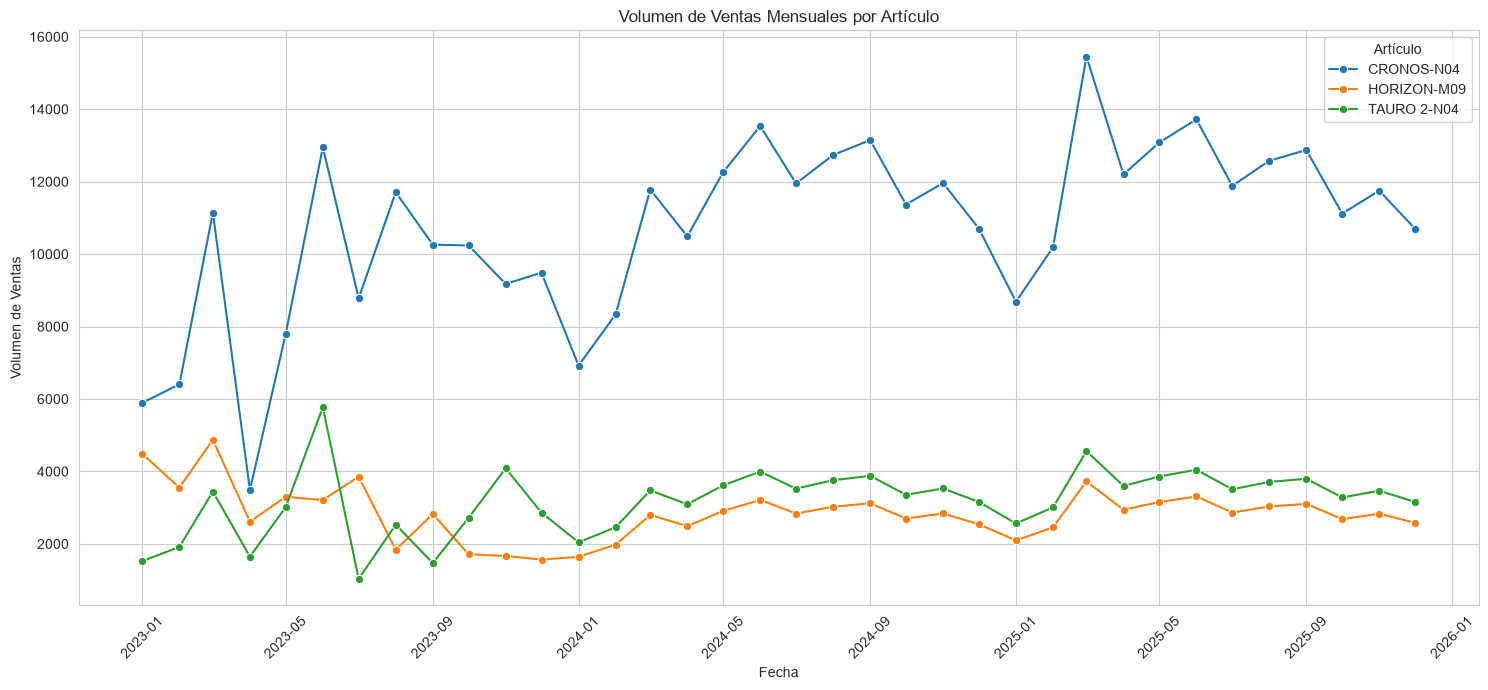

In [7]:
graficos.series_historicas(df_long);


## 4. Manejo de Nulos y Validación de Consistencia

Verificamos valores faltantes y validamos que no existan ventas negativas. Si hubiera nulos,
para series temporales se recomienda interpolación lineal por artículo (código de ejemplo
incluido y comentado).

In [8]:
print(datos.validar_calidad_de_la_serie(df_long))

# Si aparecieran nulos, la estrategia recomendada para series temporales es
# interpolar dentro de cada artículo:
#     df_long = datos.interpolar_nulos(df_long)


Valores nulos en 'Volumen_Ventas': 0
Validación OK: no se encontraron volúmenes de ventas negativos.


## 5. Preparación de Datos para Prophet

Prophet requiere dos columnas: `ds` (fecha) e `y` (valor a pronosticar). Como hay varios
artículos, entrenaremos **un modelo Prophet por artículo**. Definimos una función auxiliar
para obtener la serie `ds/y` de un artículo dado.

In [9]:
df_prophet = datos.a_formato_prophet(df_long)
articulos = sorted(df_prophet['Articulo'].unique())
ultima_fecha = df_prophet['ds'].max()

print(f"Artículos a modelar: {articulos}")
display(df_prophet.head())


Artículos a modelar: ['CRONOS-N04', 'HORIZON-M09', 'TAURO 2-N04']


,Articulo,ds,y
0,CRONOS-N04,2023-01-01,5895
1,CRONOS-N04,2023-02-01,6405
2,CRONOS-N04,2023-03-01,11145
3,CRONOS-N04,2023-04-01,3484
4,CRONOS-N04,2023-05-01,7805


## 6. Optimización de Hiperparámetros con Random Search

Mantenemos el **mismo algoritmo** que usaba la versión LSTM del notebook: **Búsqueda Aleatoria
(Random Search)**. En lugar de probar todas las combinaciones (Grid) o usar optimización
bayesiana, muestreamos `n_iter` combinaciones de hiperparámetros y nos quedamos con la mejor.

**Espacio de búsqueda** (`muestrear_hiperparametros`):

| Hiperparámetro | Distribución / valores |
|---|---|
| `changepoint_prior_scale` | log-uniforme en `[0.01, 0.5]` (flexibilidad de la tendencia) |
| `seasonality_prior_scale` | log-uniforme en `[1, 10]` (fuerza de la estacionalidad) |
| `seasonality_mode` | `{additive, multiplicative}` |
| `n_changepoints` | `{5, 10, 15, 20, 25}` |
| `yearly_seasonality` | `{True, 5, 8, 10}` (orden de Fourier anual) |

> El rango de `seasonality_prior_scale` se acota a `[1, 10]` (en vez de empezar en `0.01`) porque
> el EDA evidencia **estacionalidad anual clara**: permitir priors ~`0.01` haría que la búsqueda
> la "apague", degradando el ajuste sin beneficio predictivo real.

**Evaluación de cada combinación:** *cross-validation* de series temporales con
`prophet.diagnostics.cross_validation` + `performance_metrics`. Como los datos son **mensuales**
(36 meses por artículo), usamos:

- `initial = 730 días` (~24 meses de entrenamiento inicial, suficiente para la estacionalidad anual),
- `period = 90 días` (~3 meses entre cortes de validación),
- `horizon = 180 días` (~6 meses de horizonte evaluado en cada corte).

La **métrica objetivo es el RMSE** (consistente con el resto del notebook), promediado sobre los
cortes de la validación cruzada.

In [10]:
# La búsqueda está implementada en planificacion/forecast/modelo.py.
# Acá solo mostramos las primeras combinaciones que produce el espacio de búsqueda.
_rng = random.Random(cfg.random_seed)
display(pd.DataFrame([modelo.muestrear_hiperparametros(_rng) for _ in range(3)]))


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,n_changepoints,yearly_seasonality
0,0.122002,1.059280,multiplicative,10,5
1,0.017261,1.266179,additive,25,10
2,0.011324,1.240781,additive,25,True


### 6.1 Ejecución del Random Search por artículo

Optimizamos **por separado para cada artículo**, ya que las tres series tienen escalas y
dinámicas distintas (ver EDA): un único set global de hiperparámetros sería subóptimo. Cada
artículo usa la misma semilla, de modo que la búsqueda es reproducible.

`N_ITER` es parametrizable (por defecto 20 combinaciones aleatorias).

In [11]:
busqueda = modelo.buscar_hiperparametros(df_prophet, articulos, cfg)
mejores_params = {a: r.params for a, r in busqueda.items()}

for articulo, r in busqueda.items():
    origen = 'cache' if r.desde_cache else 'búsqueda'
    print(f"[{articulo}] mejor {cfg.metrica}_cv = {r.score:.2f}  ({origen})")

print("\nMejores hiperparámetros por artículo (Random Search):")
resumen_hiperparametros = modelo.tabla_hiperparametros(busqueda, cfg.metrica)
display(resumen_hiperparametros)


[CRONOS-N04] mejor rmse_cv = 1812.68  (cache)
[HORIZON-M09] mejor rmse_cv = 249.88  (cache)
[TAURO 2-N04] mejor rmse_cv = 338.36  (cache)

Mejores hiperparámetros por artículo (Random Search):


,Articulo,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,n_changepoints,yearly_seasonality,rmse_cv
0,CRONOS-N04,0.335254,2.508421,additive,10,10,1812.68
1,HORIZON-M09,0.122002,1.059280,multiplicative,10,5,249.88
2,TAURO 2-N04,0.100264,6.448081,additive,10,10,338.36


## 7. Evaluación del Modelo

Reportamos **dos R² complementarios**, porque miden cosas distintas y es importante no confundirlos:

| Métrica | Qué mide | Valor en estos datos |
|---|---|---|
| **R² de ajuste (in-sample)** | Cuánta varianza del histórico explica el modelo (bondad de ajuste) | **0.59 – 0.97** |
| **R² out-of-sample (hold-out 12m)** | Capacidad real de pronosticar meses no vistos | **negativo** (ver 7.2) |

> **Nota honesta sobre el R²:** un R² de ajuste alto solo indica que el modelo reproduce datos que
> ya vio. La capacidad de pronosticar se mide en 7.2, con los últimos 12 meses, que el modelo no ve
> al entrenar. Ahí el R² puede ser negativo: significa que el pronóstico se aleja del real más que
> el simple promedio del período de prueba. Por eso el R² "alto" que se suele esperar corresponde
> al **ajuste in-sample**, que calculamos en 7.1.

### 7.1 R² de ajuste (in-sample)

Reentrenamos cada modelo con su mejor combinación de hiperparámetros sobre **todo** el histórico
y comparamos `yhat` contra `y` en el período observado. Mismas métricas que el resto del notebook
(MSE, RMSE, MAE, MAPE, R²).

> `modelo.ajustar_modelos_por_articulo` entrena una sola vez por artículo y predice el histórico y el horizonte
> futuro en la misma pasada: el objeto `ajustes` que se arma acá es el que usa la **Sección 8**,
> sin reentrenar ni volver a predecir.

In [12]:
# Un solo ajuste por artículo: el mismo modelo se reutiliza para el pronóstico (Sección 8).
ajustes = modelo.ajustar_modelos_por_articulo(df_prophet, articulos, mejores_params, cfg)

metricas_ajuste = evaluacion.metricas_de_ajuste_historico(ajustes, df_prophet)
print("R² de ajuste (in-sample) de Prophet sobre el histórico:")
display(metricas_ajuste.round(2))
print("R² de ajuste promedio:", round(metricas_ajuste['R2'].mean(), 2))


R² de ajuste (in-sample) de Prophet sobre el histórico:


,Articulo,MSE,RMSE,MAE,MAPE,R2
0,CRONOS-N04,164668.29,405.79,328.61,3.31,0.97
1,HORIZON-M09,212069.85,460.51,365.00,14.24,0.59
2,TAURO 2-N04,50521.67,224.77,172.01,6.07,0.94


R² de ajuste promedio: 0.84


### 7.2 Validación out-of-sample (hold-out de 12 meses)

Reservamos los **últimos 12 meses** (un ciclo estacional completo) como prueba, entrenamos con
el resto y medimos el error de pronóstico real sobre esos meses, que el modelo no vio.

In [13]:
metricas_holdout = evaluacion.metricas_de_validacion_out_of_sample(
    df_prophet, articulos, mejores_params, cfg)

print(f"Prophet — validación out-of-sample (últimos {cfg.test_periods} meses):")
display(metricas_holdout.round(2))
print(f"R² out-of-sample promedio (Prophet): {metricas_holdout['R2'].mean():.2f}")


Prophet — validación out-of-sample (últimos 12 meses):


,Articulo,MSE,RMSE,MAE,MAPE,R2
0,CRONOS-N04,15797047.85,3974.55,3912.83,32.85,-4.57
1,HORIZON-M09,595802.16,771.88,687.90,25.12,-2.62
2,TAURO 2-N04,2057302.08,1434.33,1319.22,39.42,-7.34


R² out-of-sample promedio (Prophet): -4.84


## 8. Pronóstico Final a 12 Meses

Usamos los modelos finales ya entrenados en la Sección 7.1 (mejores hiperparámetros, serie
histórica completa) y pronosticamos los próximos `FORECAST_HORIZON` meses. Recortamos a 0
cualquier predicción negativa (las ventas no pueden serlo).

In [14]:
prophet_forecasts, prophet_insample = resultados.separar_ajuste_historico_y_pronostico(ajustes)

print(f"Pronóstico generado: {cfg.forecast_horizon} meses x {len(articulos)} artículos "
      f"(+ {len(prophet_insample)} filas de ajuste in-sample para el export)")
display(prophet_forecasts.head(cfg.forecast_horizon))


Pronóstico generado: 12 meses x 3 artículos (+ 108 filas de ajuste in-sample para el export)


,Articulo,Fecha,Volumen_Ventas
0,CRONOS-N04,2026-01-01,7781.421665
1,CRONOS-N04,2026-02-01,8751.093871
2,CRONOS-N04,2026-03-01,13682.010205
3,CRONOS-N04,2026-04-01,8131.821796
4,CRONOS-N04,2026-05-01,10696.592359
5,CRONOS-N04,2026-06-01,13604.874582
6,CRONOS-N04,2026-07-01,10077.121070
7,CRONOS-N04,2026-08-01,11649.127619
8,CRONOS-N04,2026-09-01,10574.575120
9,CRONOS-N04,2026-10-01,9558.925042


## 9. Combinar Histórico + Pronóstico

In [15]:
df_combinado = resultados.combinar_historico_y_pronostico(df_historico, prophet_forecasts)
display(df_combinado.tail())


,Articulo,Fecha,Volumen_Ventas
139,TAURO 2-N04,2026-08-01,3649.072107
140,TAURO 2-N04,2026-09-01,3040.283583
141,TAURO 2-N04,2026-10-01,3464.295602
142,TAURO 2-N04,2026-11-01,4256.098463
143,TAURO 2-N04,2026-12-01,3351.848957


## 10. Visualización del Pronóstico

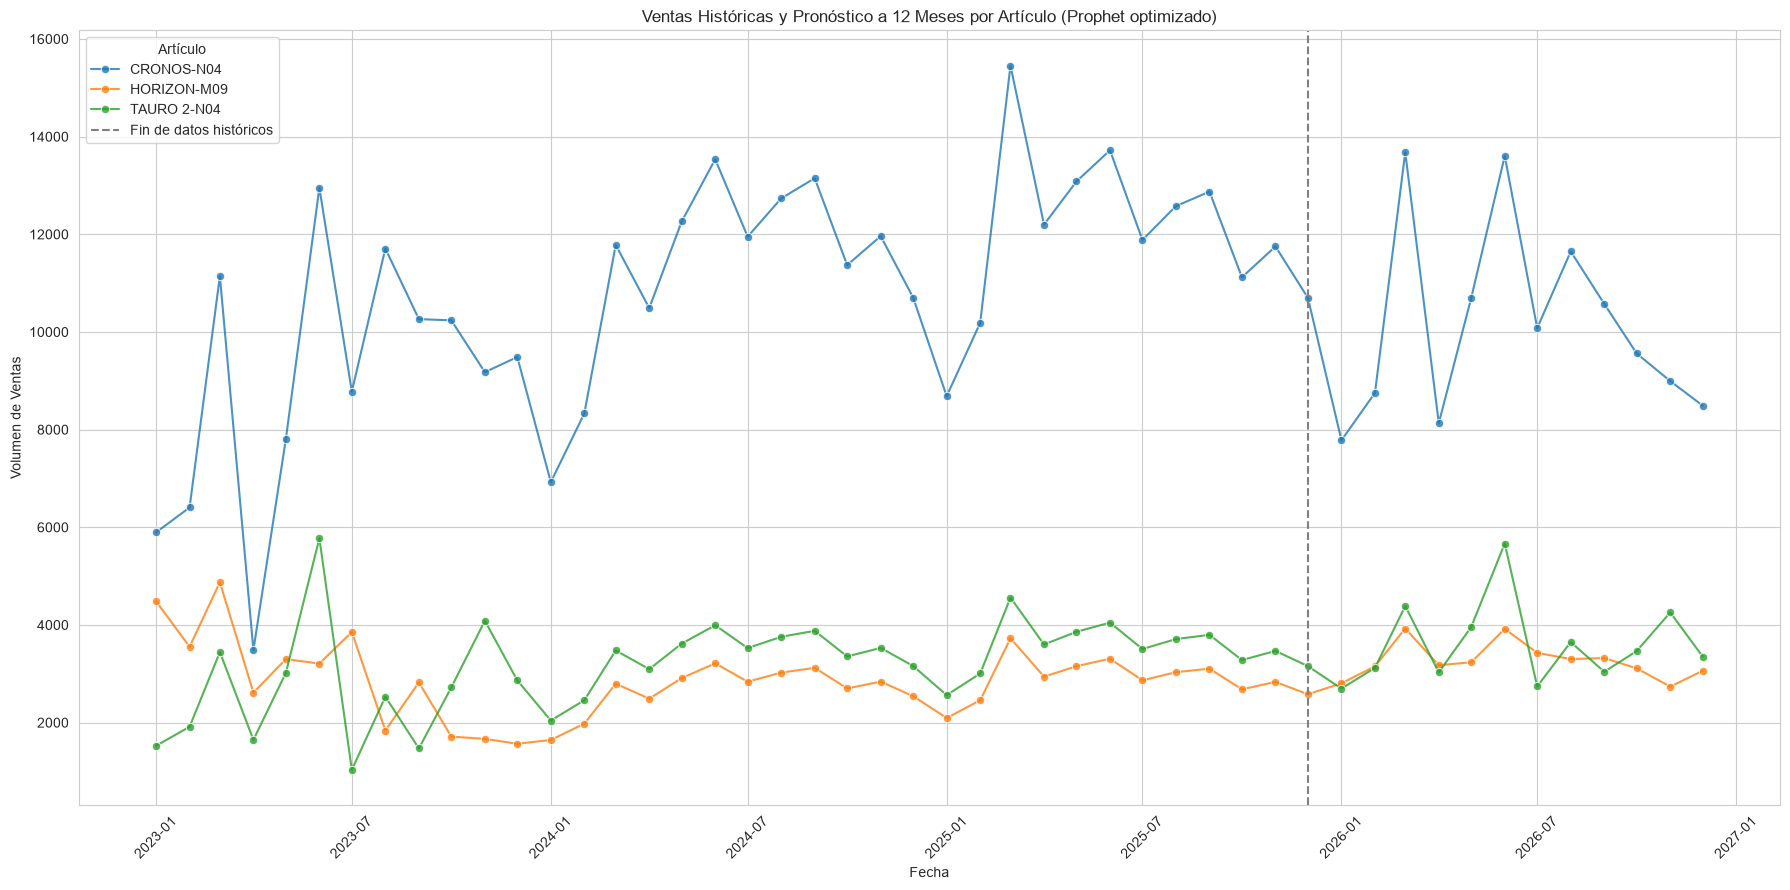

In [16]:
graficos.historico_y_pronostico(df_combinado, ultima_fecha, cfg.forecast_horizon);


## 11. Exportar Pronóstico a Excel

Formato de salida: **`Articulo | Fecha | Ventas | Tipo`**, combinando:

- `Tipo = Historico` → ventas reales (36 meses por artículo).
- `Tipo = Pronostico` → **yhat del modelo para todo el rango** (36 meses in-sample + 12 futuros).

> **Contrato de datos con `Insumos_Criticos_KMeans.ipynb`**: el yhat in-sample se exporta
> a propósito. El notebook de insumos críticos estima la variabilidad de la demanda
> (σ_d) a partir del error in-sample (`Historico − Pronostico` en las mismas fechas);
> si se exportara solo el tramo futuro, ese cálculo quedaría sin datos.

In [17]:
df_final_export = resultados.exportar_pronostico_a_excel(df_historico, prophet_insample, prophet_forecasts,
                                      cfg.output_xlsx)

print(f"Pronóstico exportado a '{cfg.output_xlsx.name}' "
      f"({(df_final_export['Tipo'] == 'Historico').sum()} filas Historico + "
      f"{(df_final_export['Tipo'] == 'Pronostico').sum()} filas Pronostico)")
display(df_final_export.head())


Pronóstico exportado a 'pronostico_ventas.xlsx' (108 filas Historico + 144 filas Pronostico)


,Articulo,Fecha,Ventas,Tipo
0,CRONOS-N04,2023-01-01,5895.000000,Historico
1,CRONOS-N04,2023-01-01,5419.924865,Pronostico
2,CRONOS-N04,2023-02-01,6405.000000,Historico
3,CRONOS-N04,2023-02-01,6259.884956,Pronostico
4,CRONOS-N04,2023-03-01,11145.000000,Historico
